# Exploratory Data Analysis (EDA)
## Flipkart Product Reviews — Sentiment Analysis
### CT107-3-3-TXSA | Group Assignment Part B — Q1

---
## Install and Import Required Libraries

In [1]:
# Install required libraries
%pip install matplotlib seaborn wordcloud pandas nltk wordninja

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard and third-party imports
import re
import warnings
import string
import wordninja
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

# Global plot style applied to all figures in this notebook
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

# Consistent colour palette across all sentiment visualisations
COLORS  = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'}
PALETTE = ['#4CAF50', '#F44336', '#FF9800']

---
## Load the Dataset

In [3]:
# Load dataset and display first 5 rows for a quick sanity check
df = pd.read_csv('../Data/Dataset-SA.csv')
print('Shape:', df.shape)
df.head()

Shape: (205052, 6)


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


---
## Dataset Overview

In [4]:
# Display high-level structural summary of the dataset
print('=== DATASET OVERVIEW ===')
print(f'Total Rows          : {len(df):,}')
print(f'Total Columns       : {df.shape[1]}')
print(f'Column Names        : {df.columns.tolist()}')
print(f'Sentiment Classes   : {df["Sentiment"].unique().tolist()}')
print(f'Unique Products     : {df["product_name"].nunique():,}')

# Coerce product_price to numeric to safely ignore 3 corrupted rows
df_price = df[pd.to_numeric(df['product_price'], errors='coerce').notna()].copy()
df_price['product_price'] = df_price['product_price'].astype(float)
print(f'Price Range (INR)   : ₹{int(df_price["product_price"].min())} – ₹{int(df_price["product_price"].max())}')

print('\n=== COLUMN DATA TYPES ===')
print(df.dtypes)

=== DATASET OVERVIEW ===
Total Rows          : 205,052
Total Columns       : 6
Column Names        : ['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']
Sentiment Classes   : ['positive', 'negative', 'neutral']
Unique Products     : 958
Price Range (INR)   : ₹59 – ₹86990

=== COLUMN DATA TYPES ===
product_name     object
product_price    object
Rate             object
Review           object
Summary          object
Sentiment        object
dtype: object


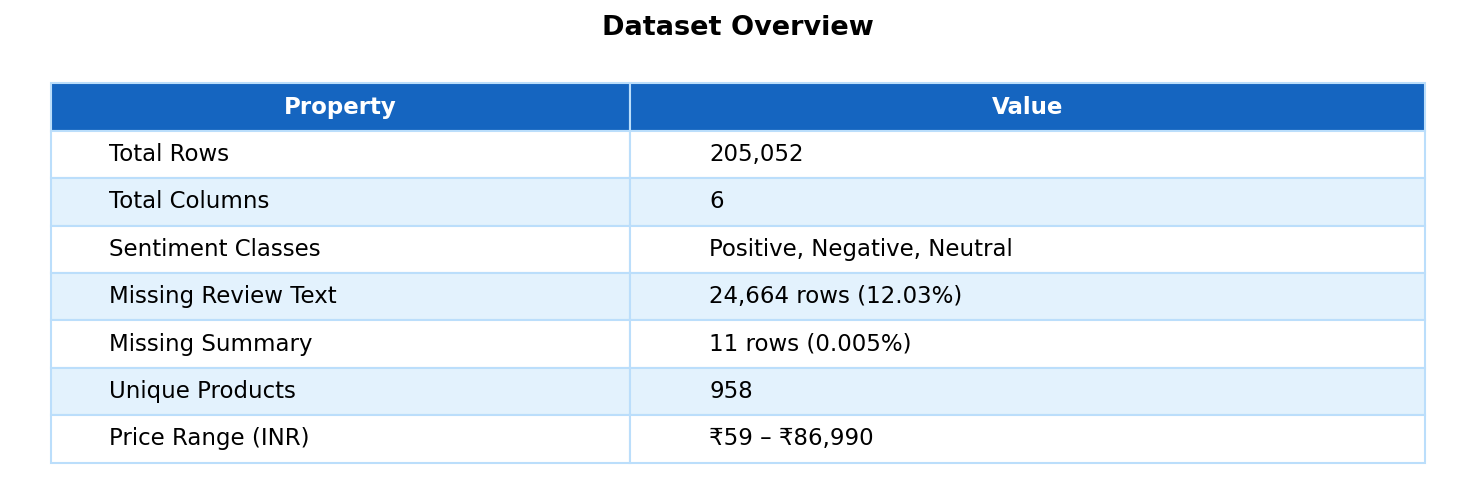

In [5]:
# Render dataset overview as a formatted table
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

overview_data = [
    ['Total Rows',          '205,052'],
    ['Total Columns',       '6'],
    ['Sentiment Classes',   'Positive, Negative, Neutral'],
    ['Missing Review Text', '24,664 rows (12.03%)'],
    ['Missing Summary',     '11 rows (0.005%)'],
    ['Unique Products',     '958'],
    ['Price Range (INR)',   '₹59 – ₹86,990'],
]

table = ax.table(
    cellText=overview_data,
    colLabels=['Property', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.4, 0.55]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Apply header and alternating row colours
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    else:
        cell.set_facecolor('#FFFFFF')
    cell.set_edgecolor('#BBDEFB')

plt.title('Dataset Overview', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## Missing Value Analysis

In [6]:
# Calculate missing value count and percentage for each column
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)

print('=== MISSING VALUE SUMMARY ===')
print(missing.to_string(index=False))

=== MISSING VALUE SUMMARY ===
       Column  Missing Count  Missing %
 product_name              0       0.00
product_price              0       0.00
         Rate              0       0.00
       Review          24664      12.03
      Summary             11       0.01
    Sentiment              0       0.00


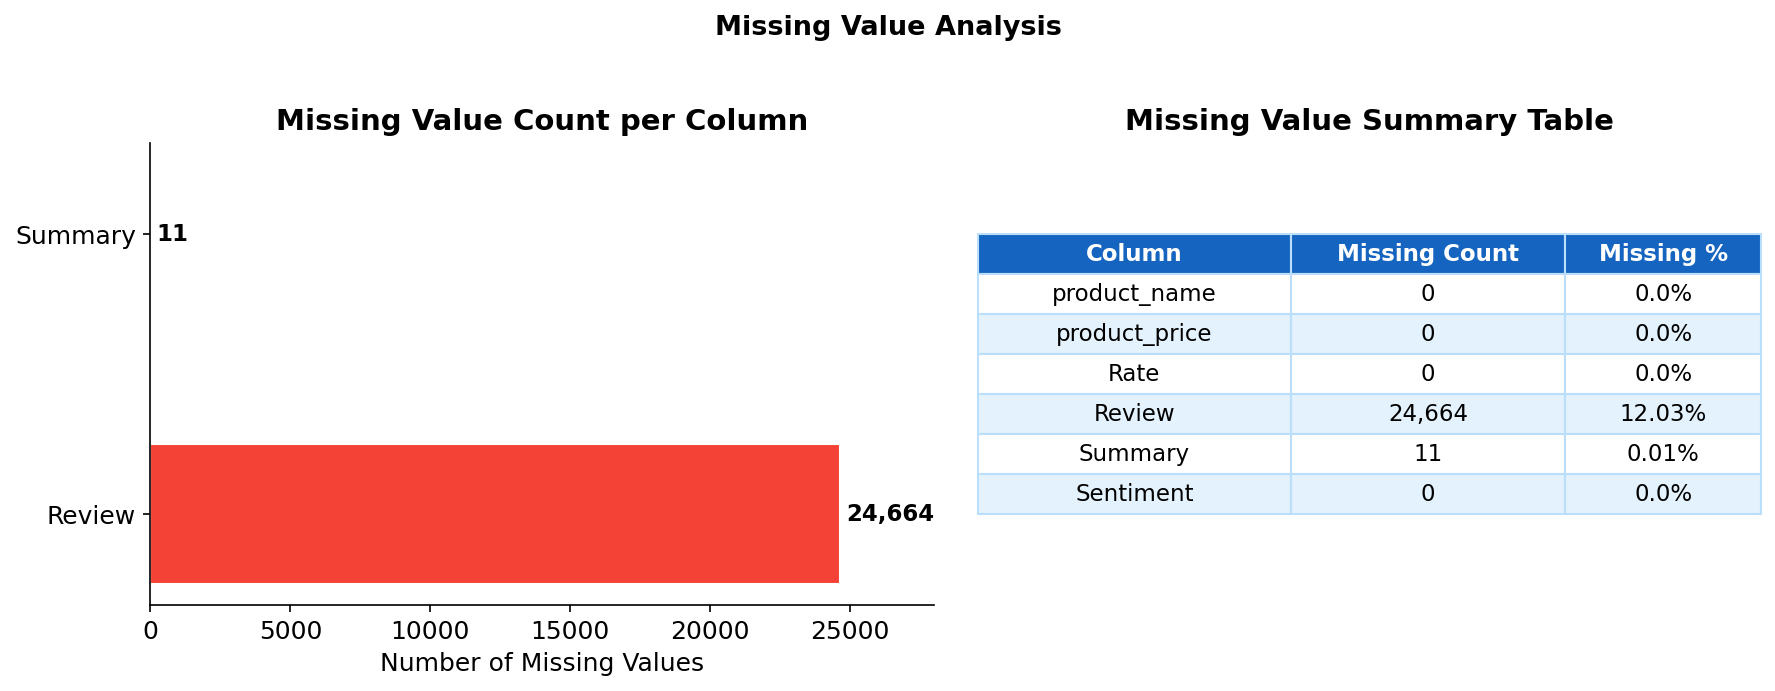

In [7]:
# Filter to only columns with missing values for cleaner visualisation
missing_nonzero = missing[missing['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart of missing counts
bars = axes[0].barh(
    missing_nonzero['Column'],
    missing_nonzero['Missing Count'],
    color=['#F44336', '#FF9800'],
    edgecolor='white', height=0.5
)
for bar, val in zip(bars, missing_nonzero['Missing Count']):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Missing Values')
axes[0].set_title('Missing Value Count per Column')
axes[0].set_xlim(0, 28000)

# Summary table with count and percentage
table_data = missing[['Column', 'Missing Count', 'Missing %']].values.tolist()
axes[1].axis('off')
t = axes[1].table(
    cellText=[[c, f'{int(m):,}', f'{p}%'] for c, m, p in table_data],
    colLabels=['Column', 'Missing Count', 'Missing %'],
    cellLoc='center', loc='center', colWidths=[0.4, 0.35, 0.25]
)
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1, 1.8)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#E3F2FD' if r % 2 == 0 else '#FFFFFF')
    cell.set_edgecolor('#BBDEFB')
axes[1].set_title('Missing Value Summary Table')

plt.suptitle('Missing Value Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Sentiment Class Distribution

In [8]:
# Count reviews and compute percentage per sentiment class
sentiment_counts = df['Sentiment'].value_counts()
sentiment_pct    = (sentiment_counts / len(df) * 100).round(1)

print('=== SENTIMENT CLASS DISTRIBUTION ===')
for sent in ['positive', 'negative', 'neutral']:
    print(f'{sent.capitalize():10s}: {sentiment_counts[sent]:,} reviews ({sentiment_pct[sent]}%)')

=== SENTIMENT CLASS DISTRIBUTION ===
Positive  : 166,581 reviews (81.2%)
Negative  : 28,232 reviews (13.8%)
Neutral   : 10,239 reviews (5.0%)


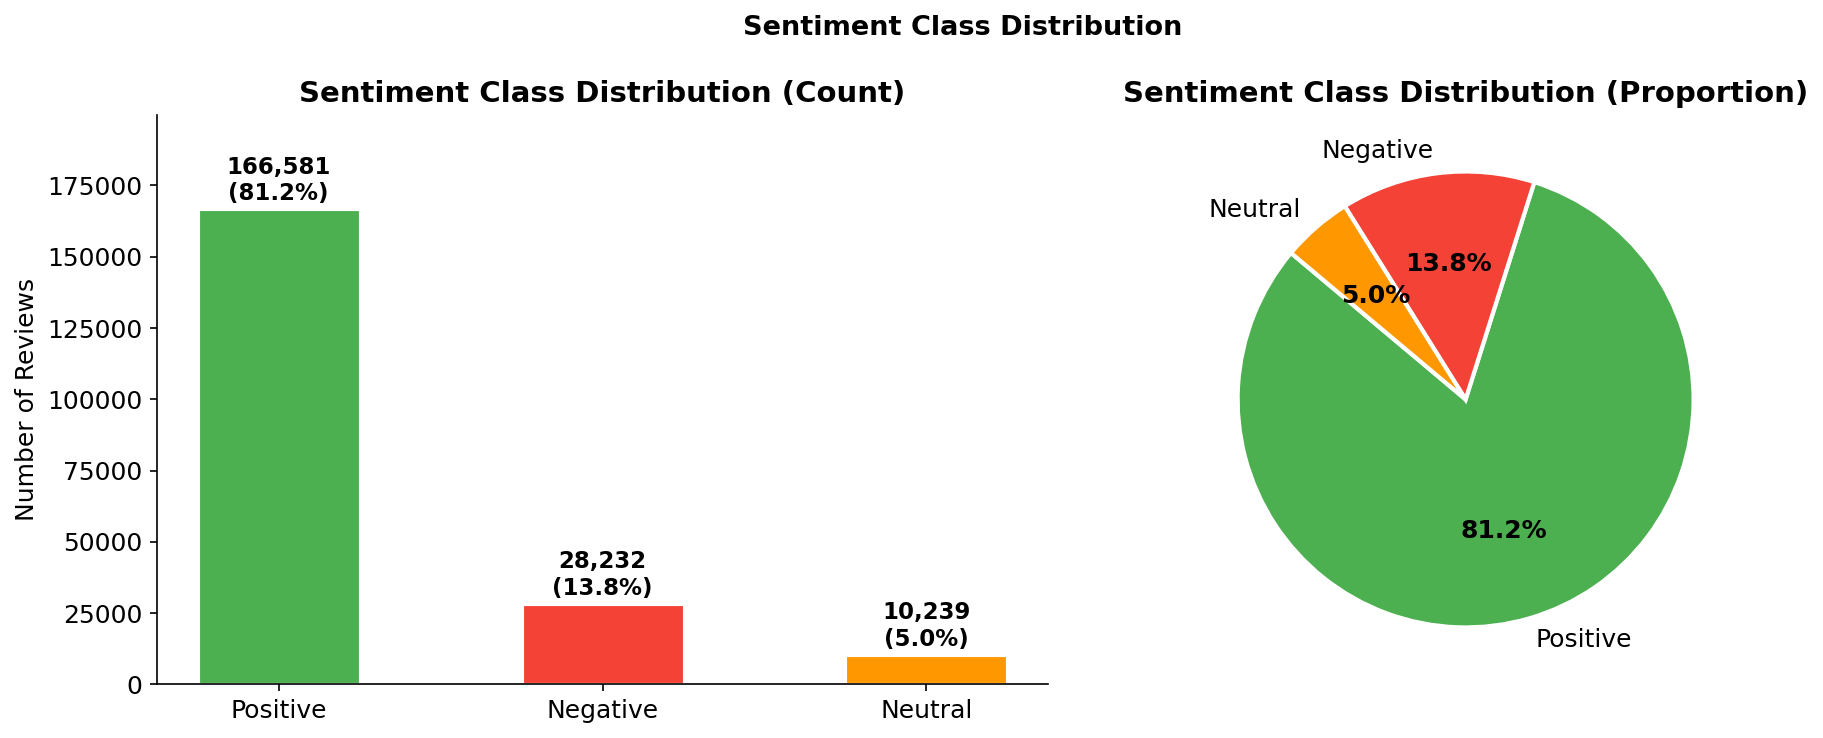

In [9]:
# Prepare counts and percentages for plotting
labels = ['Positive', 'Negative', 'Neutral']
counts = [sentiment_counts.get('positive', 0), sentiment_counts.get('negative', 0), sentiment_counts.get('neutral', 0)]
pcts   = [sentiment_pct.get('positive', 0),    sentiment_pct.get('negative', 0),    sentiment_pct.get('neutral', 0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart with count and percentage annotations
bars = axes[0].bar(labels, counts, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, pct, cnt in zip(bars, pcts, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
                 f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Sentiment Class Distribution (Count)')
axes[0].set_ylim(0, max(counts) * 1.2)

# Pie chart showing class proportions
wedges, texts, autotexts = axes[1].pie(
    counts, labels=labels, colors=PALETTE, autopct='%1.1f%%',
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Sentiment Class Distribution (Proportion)')

plt.suptitle('Sentiment Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Star Rating Distribution and Sentiment Mapping

In [10]:
# Filter to valid numeric ratings only — removes 3 corrupted rows
valid_rates = ['1', '2', '3', '4', '5']
df_rate = df[df['Rate'].isin(valid_rates)].copy()
df_rate['Rate'] = df_rate['Rate'].astype(int)
rate_counts = df_rate['Rate'].value_counts().sort_index()

print('=== STAR RATING DISTRIBUTION ===')
for star, count in rate_counts.items():
    print(f'{star} Star(s): {count:,} reviews')
print(f'\nRows removed due to corrupted Rate values: {len(df) - len(df_rate)}')

=== STAR RATING DISTRIBUTION ===
1 Star(s): 21,300 reviews
2 Star(s): 6,491 reviews
3 Star(s): 16,599 reviews
4 Star(s): 41,894 reviews
5 Star(s): 118,765 reviews

Rows removed due to corrupted Rate values: 3


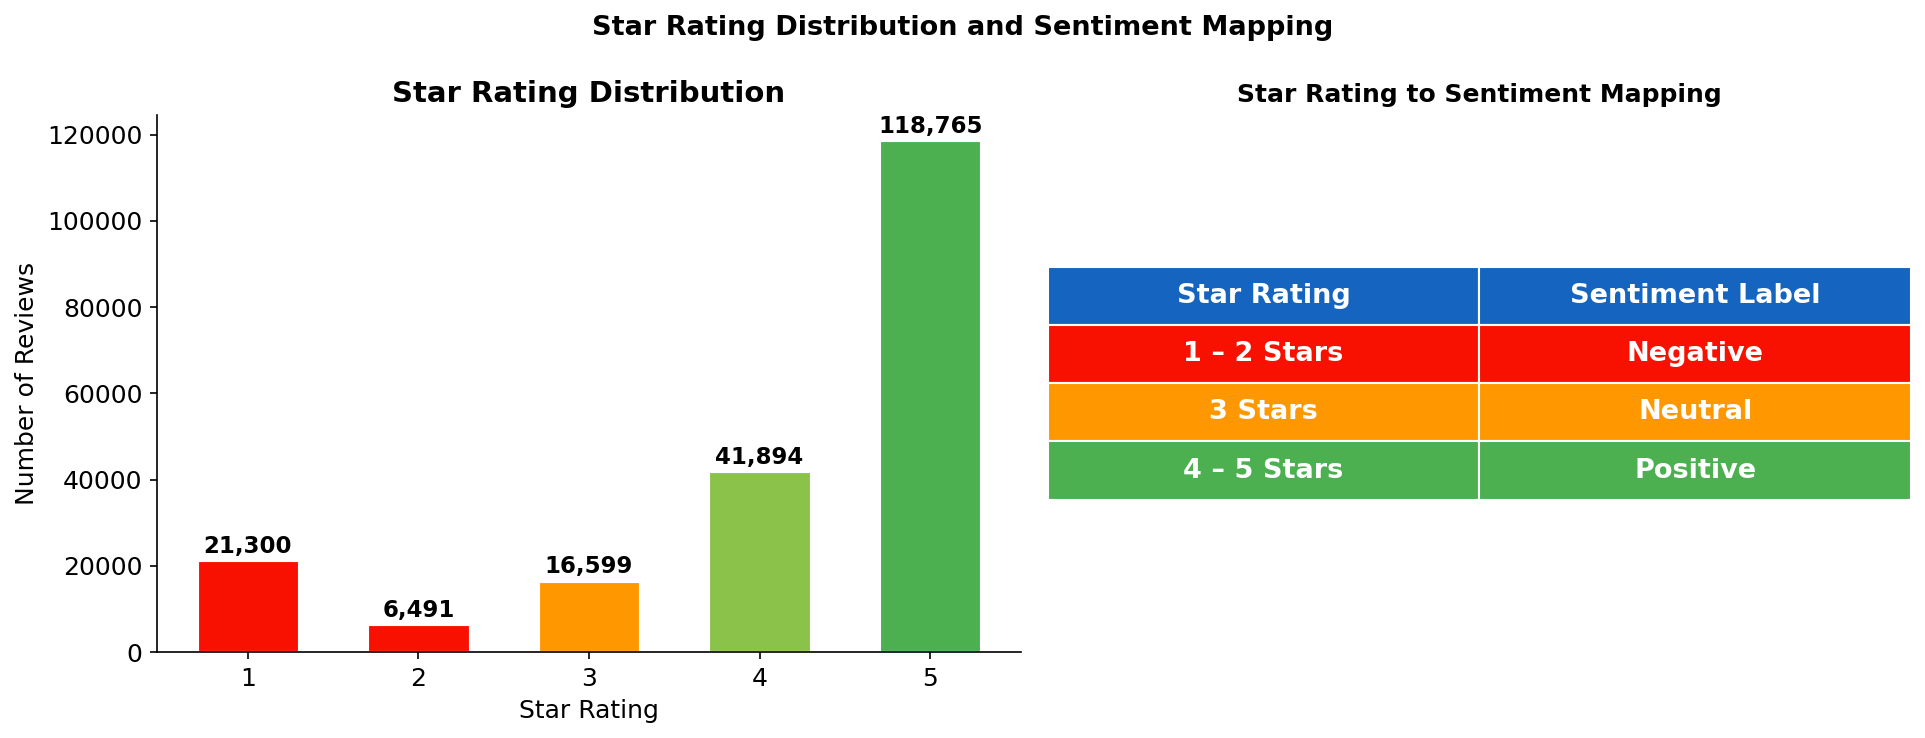

In [11]:
# Colour bars to match sentiment mapping: red=negative, orange=neutral, green=positive
rate_colors = ['#F81100', '#F81100', '#FF9800', '#8BC34A', '#4CAF50']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of review counts per star rating
bars = axes[0].bar([str(r) for r in rate_counts.index], rate_counts.values,
                   color=rate_colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, rate_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Star Rating Distribution')

# Sentiment mapping reference table
map_data = [['1 – 2 Stars', 'Negative'], ['3 Stars', 'Neutral'], ['4 – 5 Stars', 'Positive']]
axes[1].axis('off')
t = axes[1].table(cellText=map_data, colLabels=['Star Rating', 'Sentiment Label'],
                  cellLoc='center', loc='center', colWidths=[0.5, 0.5])
t.auto_set_font_size(False)
t.set_fontsize(13)
t.scale(1, 2.5)
row_colors = ['#F81100', '#FF9800', '#4CAF50']
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[r - 1])
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')
axes[1].set_title('Star Rating to Sentiment Mapping', fontweight='bold', fontsize=12)

plt.suptitle('Star Rating Distribution and Sentiment Mapping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary Length Distribution

In [12]:
# Compute word count per summary and display stats by sentiment class
df_summ = df.dropna(subset=['Summary']).copy()
df_summ['word_count'] = df_summ['Summary'].str.split().str.len()

print('=== SUMMARY WORD COUNT STATS BY SENTIMENT ===')
for sent in ['positive', 'negative', 'neutral']:
    sub = df_summ[df_summ['Sentiment'] == sent]['word_count']
    print(f'{sent.capitalize():10s}: mean={sub.mean():.1f}  median={sub.median():.0f}  max={sub.max()}')

=== SUMMARY WORD COUNT STATS BY SENTIMENT ===
Positive  : mean=7.3  median=3  max=108
Negative  : mean=10.7  median=5  max=106
Neutral   : mean=6.3  median=3  max=104


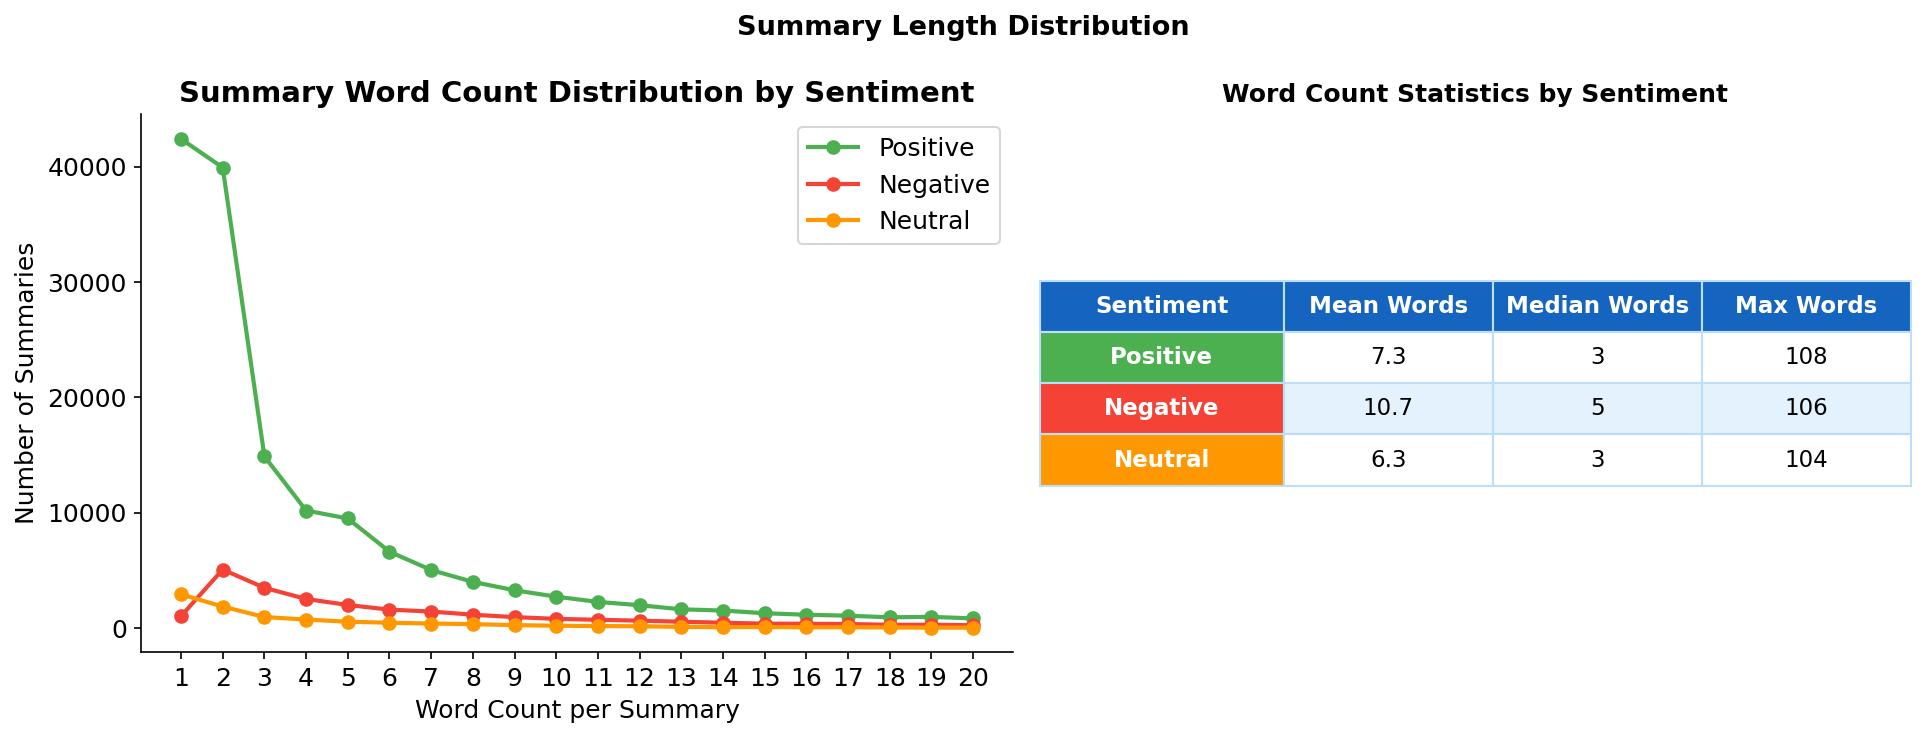

Overall mean summary length: 7.8 words


In [13]:
# Cap x-axis at 20 words for readability — max summary is 108 words
cap = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Line chart of word count frequency per sentiment class
for sent, col in zip(['positive', 'negative', 'neutral'], PALETTE):
    subset    = df_summ[df_summ['Sentiment'] == sent]['word_count']
    counts_wc = subset[subset <= cap].value_counts().sort_index()
    axes[0].plot(counts_wc.index, counts_wc.values, marker='o',
                 color=col, label=sent.capitalize(), linewidth=2)
axes[0].set_xlabel('Word Count per Summary')
axes[0].set_ylabel('Number of Summaries')
axes[0].set_title('Summary Word Count Distribution by Sentiment')
axes[0].legend()
axes[0].set_xticks(range(1, cap + 1))

# Stats table showing mean, median and true max per sentiment class
stats_data = []
for sent in ['positive', 'negative', 'neutral']:
    sub = df_summ[df_summ['Sentiment'] == sent]['word_count']
    stats_data.append([sent.capitalize(), f'{sub.mean():.1f}', f'{int(sub.median())}', f'{sub.max()}'])

axes[1].axis('off')
t = axes[1].table(
    cellText=stats_data,
    colLabels=['Sentiment', 'Mean Words', 'Median Words', 'Max Words'],
    cellLoc='center', loc='center', colWidths=[0.28, 0.24, 0.24, 0.24]
)
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1, 2.2)
row_colors_s = ['#4CAF50', '#F44336', '#FF9800']
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        if c == 0:
            cell.set_facecolor(row_colors_s[r - 1])
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#E3F2FD' if r % 2 == 0 else '#FFFFFF')
    cell.set_edgecolor('#BBDEFB')
axes[1].set_title('Word Count Statistics by Sentiment', fontweight='bold', fontsize=12)

plt.suptitle('Summary Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

overall_mean = df_summ['word_count'].mean()
print(f'Overall mean summary length: {overall_mean:.1f} words')

---
## Top Frequent Words — Before Stopword Removal

In [14]:
# Tokenize all summaries using NLTK and count raw word frequencies
all_words = []
for text in df_summ['Summary'].dropna():
    tokens = word_tokenize(str(text).lower())
    # Keep alphabetic tokens only — removes punctuation and numbers
    tokens = [w for w in tokens if w.isalpha()]
    all_words.extend(tokens)

top_before = Counter(all_words).most_common(15)

# Print top 15 words before stopword removal
print('TOP 15 WORDS — BEFORE stopword removal:')
for word, count in top_before:
    print(f'  {word:20s}: {count:,}')

TOP 15 WORDS — BEFORE stopword removal:
  good                : 81,951
  product             : 61,404
  is                  : 48,490
  very                : 44,785
  nice                : 40,449
  and                 : 36,942
  the                 : 34,139
  it                  : 31,747
  for                 : 29,890
  quality             : 24,759
  this                : 24,258
  i                   : 22,787
  to                  : 21,681
  not                 : 21,023
  in                  : 16,775


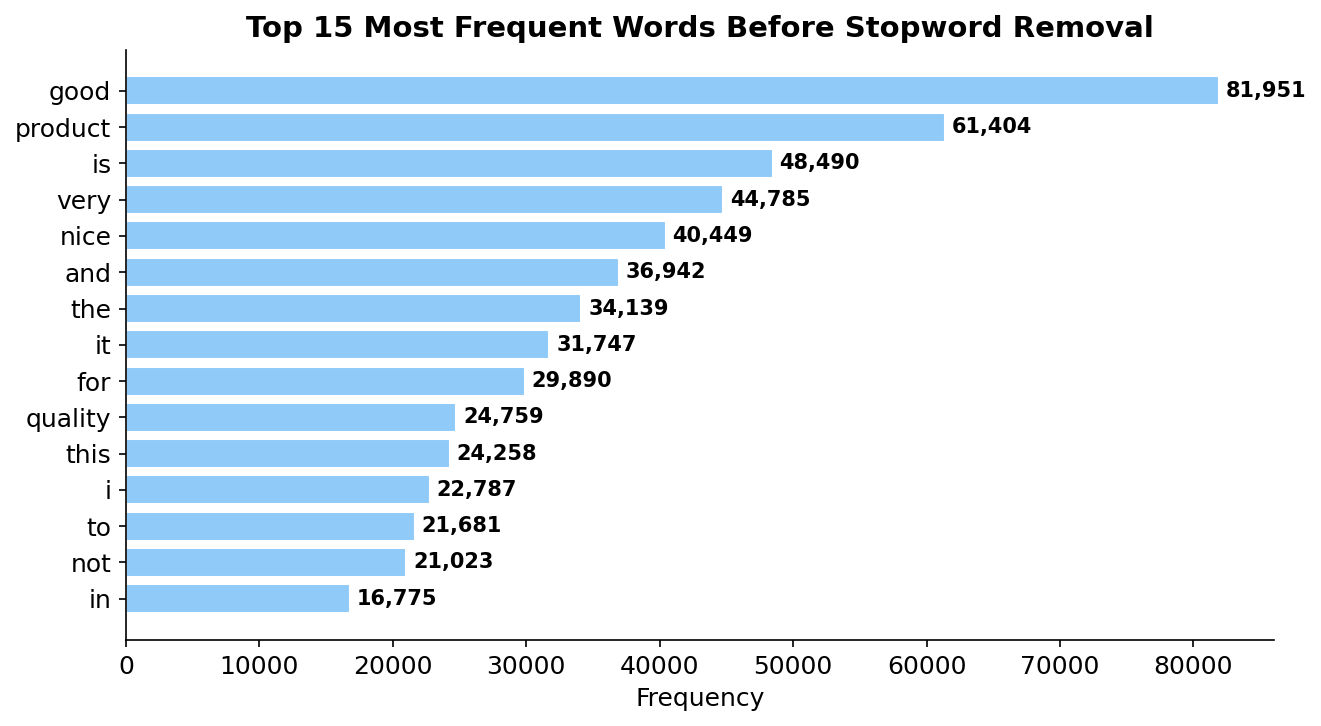

In [15]:
# Horizontal bar chart of raw word frequencies before stopword removal
words, counts = zip(*top_before)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(words[::-1], counts[::-1], color='#90CAF9', edgecolor='white')
for bar, val in zip(ax.patches, counts[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 15 Most Frequent Words Before Stopword Removal', fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Punctuation and Special Character Analysis

In [16]:
# Analyse noise characteristics directly on raw Summary text
punctuation_set = set(string.punctuation)

summary_stats = {
    'has_punctuation'  : 0,
    'has_special_chars': 0,
    'has_numbers'      : 0,
    'has_uppercase'    : 0,
    'has_concat_tokens': 0,   # Tokens > 14 characters — likely two words merged without space
}

total = len(df_summ)

for text in df_summ['Summary'].dropna():
    raw = str(text)  # Check against raw string, not tokenised version

    if any(c in punctuation_set for c in raw):
        summary_stats['has_punctuation'] += 1

    if any(not c.isalnum() and not c.isspace() for c in raw):
        summary_stats['has_special_chars'] += 1

    if any(c.isdigit() for c in raw):
        summary_stats['has_numbers'] += 1

    if any(c.isupper() for c in raw):
        summary_stats['has_uppercase'] += 1

    if re.search(r'\b\w{14,}\b', raw):
        summary_stats['has_concat_tokens'] += 1

print('=== NOISE CHARACTERISTICS IN SUMMARY COLUMN ===')
labels = {
    'has_punctuation'  : 'Contains punctuation',
    'has_special_chars': 'Contains special characters',
    'has_numbers'      : 'Contains numbers',
    'has_uppercase'    : 'Contains uppercase letters',
    'has_concat_tokens': 'Contains concatenated tokens',
}
for key, label in labels.items():
    n = summary_stats[key]
    print(f'  {label:42s}: {n:,} ({n / total * 100:.1f}%)')


=== NOISE CHARACTERISTICS IN SUMMARY COLUMN ===
  Contains punctuation                      : 12 (0.0%)
  Contains special characters               : 12 (0.0%)
  Contains numbers                          : 15,784 (7.7%)
  Contains uppercase letters                : 1 (0.0%)
  Contains concatenated tokens              : 3,950 (1.9%)


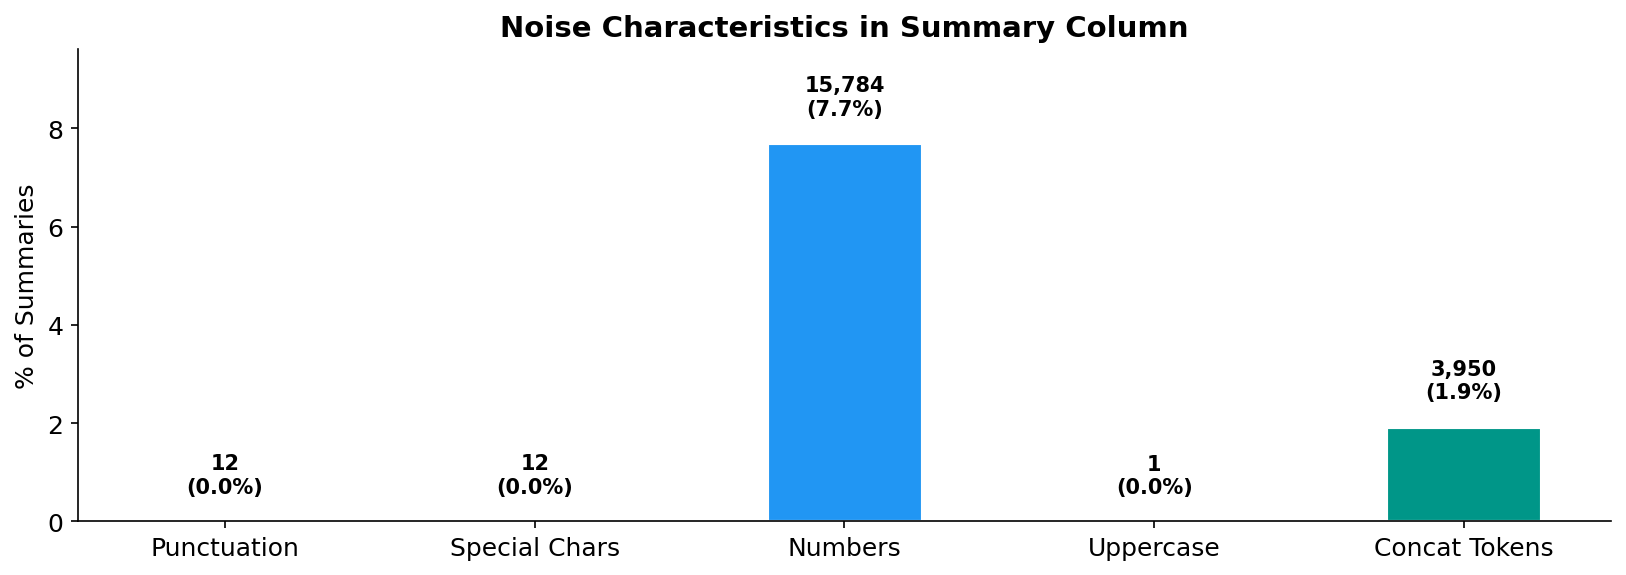

In [17]:
# Bar chart of noise prevalence
categories = ['Punctuation', 'Special Chars', 'Numbers', 'Uppercase', 'Concat Tokens']
values     = [summary_stats[k] for k in summary_stats]
pcts       = [v / total * 100 for v in values]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(categories, pcts,
              color=['#F44336', '#FF9800', '#2196F3', '#9C27B0', '#009688'],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val, pct in zip(bars, values, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('% of Summaries')
ax.set_title('Noise Characteristics in Summary Column', fontweight='bold')
ax.set_ylim(0, max(pcts) * 1.25)
plt.tight_layout()
plt.show()


---
## Duplicate Analysis

In [18]:
# Group by (product_name, Summary) to detect duplicates within product context
# Same text across different products is natural — same text for the same product is not
grp = df.dropna(subset=['Summary']).groupby(['product_name', 'Summary'])

exact_dup           = df.dropna(subset=['Summary']).duplicated().sum()
consistent_rows     = 0
inconsistent_groups = 0
inconsistent_rows   = 0

for (prod, summ), group in grp:
    if len(group) > 1:
        if group['Sentiment'].nunique() == 1:
            # Same label across all rows — safe to deduplicate
            consistent_rows += len(group) - 1
        else:
            # Conflicting labels for same product+summary — irresolvable label noise
            inconsistent_groups += 1
            inconsistent_rows   += len(group)

print('=== DUPLICATE ANALYSIS (grouped by product + Summary) ===')
print(f'Exact full-row duplicates                        : {exact_dup:,}')
print(f'Same product+summary, consistent label (to dedup): {consistent_rows:,}')
print(f'Same product+summary, conflicting labels (groups): {inconsistent_groups:,}')
print(f'Same product+summary, conflicting labels (rows)  : {inconsistent_rows:,}')
print(f'\nTotal rows affected                              : {exact_dup + consistent_rows + inconsistent_rows:,}')

=== DUPLICATE ANALYSIS (grouped by product + Summary) ===
Exact full-row duplicates                        : 34,374
Same product+summary, consistent label (to dedup): 62,746
Same product+summary, conflicting labels (groups): 563
Same product+summary, conflicting labels (rows)  : 7,527

Total rows affected                              : 104,647


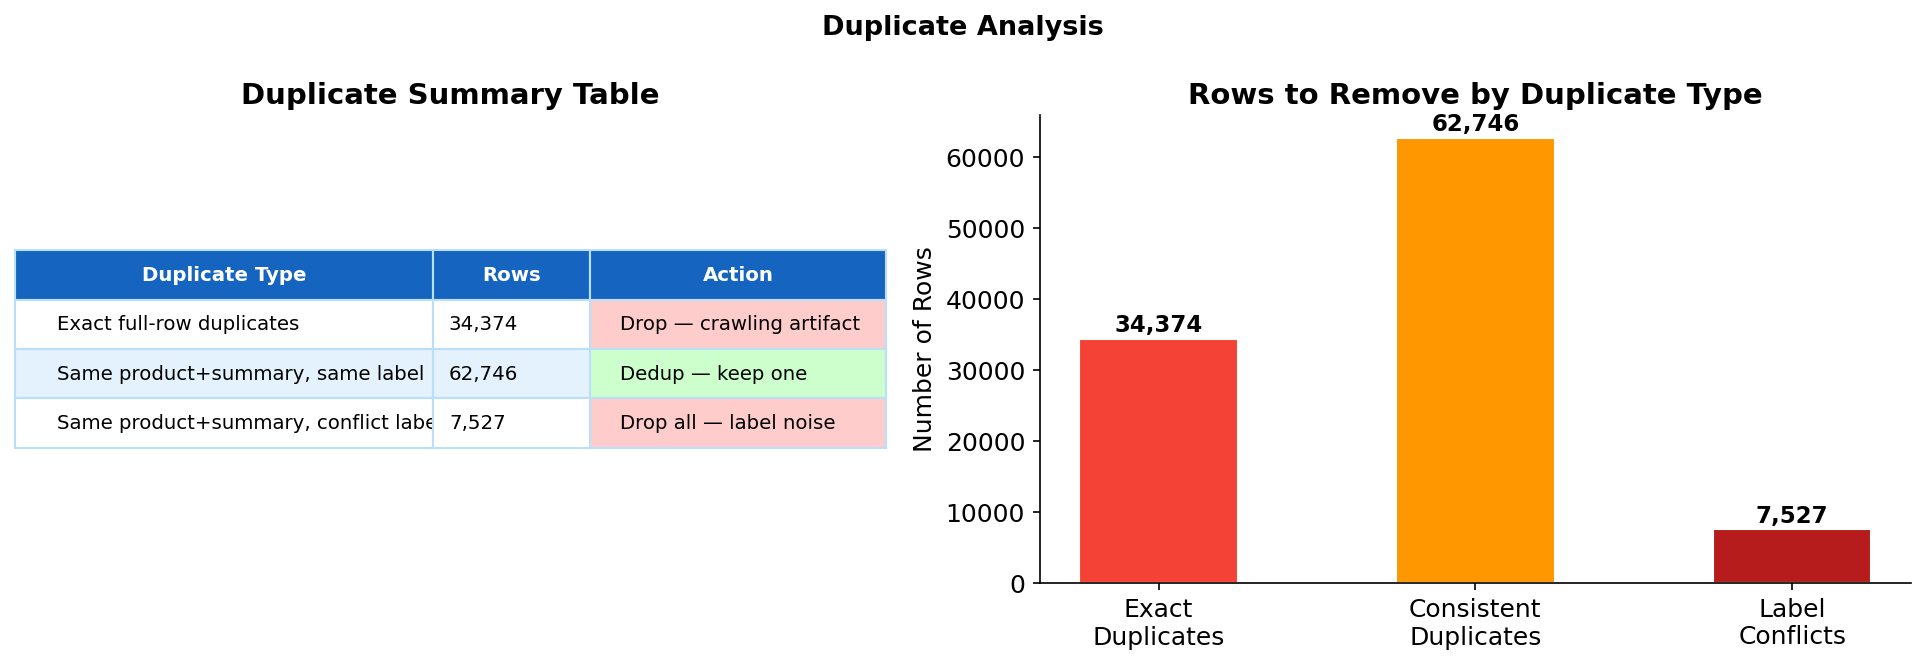

In [19]:
# Visualise duplicate findings — table (left) and bar chart (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].axis('off')
table_data = [
    ['Exact full-row duplicates',            f'{exact_dup:,}',         'Drop — crawling artifact'],
    ['Same product+summary, same label',     f'{consistent_rows:,}',   'Dedup — keep one'],
    ['Same product+summary, conflict label', f'{inconsistent_rows:,}', 'Drop all — label noise'],
]
t = axes[0].table(
    cellText=table_data,
    colLabels=['Duplicate Type', 'Rows', 'Action'],
    cellLoc='left', loc='center', colWidths=[0.48, 0.18, 0.34]
)
t.auto_set_font_size(False)
t.set_fontsize(9.5)
t.scale(1, 2.2)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2 and r > 0:
        # Red for drop, green for dedup
        cell.set_facecolor('#ffcccc' if 'Drop' in cell.get_text().get_text() else '#ccffcc')
    else:
        cell.set_facecolor('#E3F2FD' if r % 2 == 0 else '#FFFFFF')
    cell.set_edgecolor('#BBDEFB')
axes[0].set_title('Duplicate Summary Table', fontweight='bold')

# Bar chart of rows removed per duplicate type
dup_labels = ['Exact\nDuplicates', 'Consistent\nDuplicates', 'Label\nConflicts']
dup_values = [exact_dup, consistent_rows, inconsistent_rows]
dup_colors = ['#F44336', '#FF9800', '#B71C1C']
bars = axes[1].bar(dup_labels, dup_values, color=dup_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, dup_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Rows')
axes[1].set_title('Rows to Remove by Duplicate Type', fontweight='bold')

plt.suptitle('Duplicate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Word Cloud by Sentiment Class

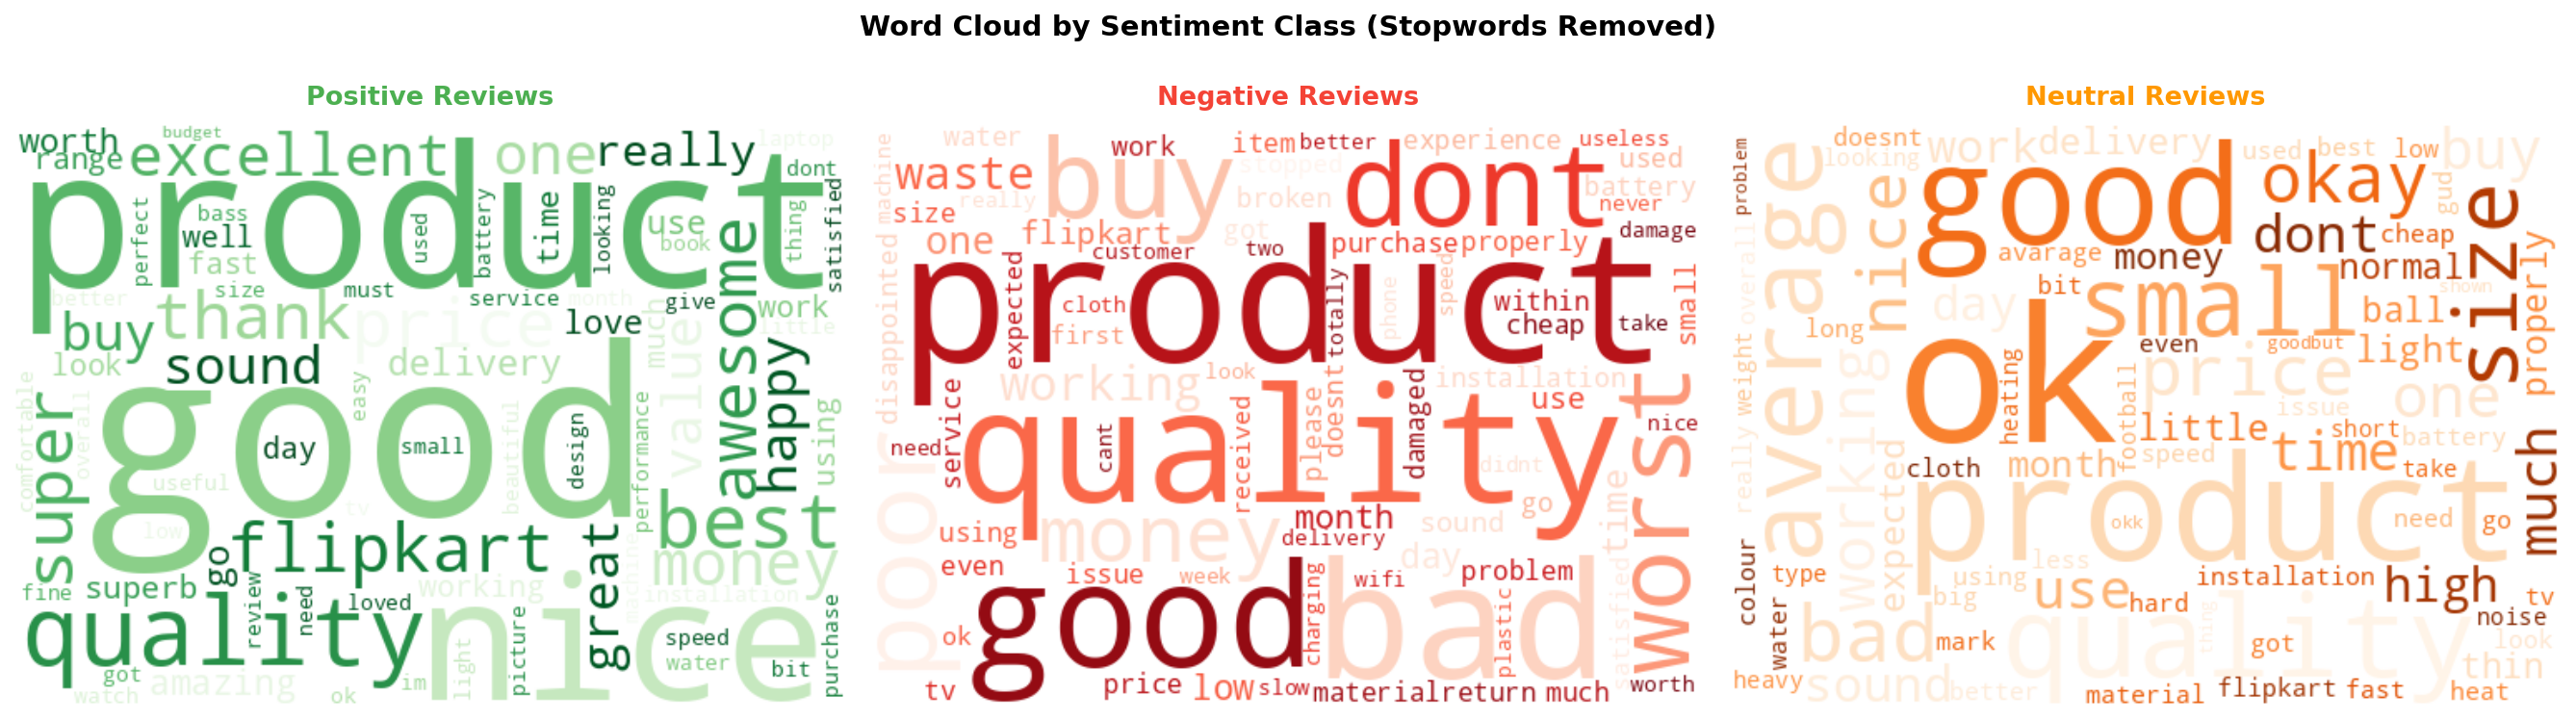

In [20]:
# Prepare text per sentiment class for word cloud — lowercase, remove noise, filter stopwords
def clean_for_wordcloud(series):
    text   = ' '.join(series.dropna().astype(str).str.lower() )
    text   = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

sentiments = ['positive', 'negative', 'neutral']
wc_colors  = ['Greens', 'Reds', 'Oranges']
titles     = ['Positive Reviews', 'Negative Reviews', 'Neutral Reviews']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sent, cmap, title in zip(axes, sentiments, wc_colors, titles):
    subset_text = clean_for_wordcloud(df_summ[df_summ['Sentiment'] == sent]['Summary'])
    # collocations=False prevents bigram grouping — single tokens only
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(subset_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', color=COLORS[sent], pad=10)

plt.suptitle('Word Cloud by Sentiment Class (Stopwords Removed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Text Sparsity Analysis

In [21]:
# Compute vocabulary size and sparsity across all Summary texts
all_tokens = []
for text in df_summ['Summary'].dropna():
    tokens = word_tokenize(str(text).lower())   # Consistent tokenisation — matches Cell 22
    tokens = [w for w in tokens if w.isalpha()]
    all_tokens.extend(tokens)

vocab_size   = len(set(all_tokens))
total_tokens = len(all_tokens)
avg_per_doc  = total_tokens / len(df_summ)

print('=== TEXT SPARSITY ANALYSIS ===')
print(f'Unique vocabulary         : {vocab_size:,} words')
print(f'Total word tokens         : {total_tokens:,}')
print(f'Average words per Summary : {avg_per_doc:.1f}')
print(f'Vocabulary used per doc   : {avg_per_doc / vocab_size * 100:.2f}%')

=== TEXT SPARSITY ANALYSIS ===
Unique vocabulary         : 41,885 words
Total word tokens         : 1,562,430
Average words per Summary : 7.6
Vocabulary used per doc   : 0.02%


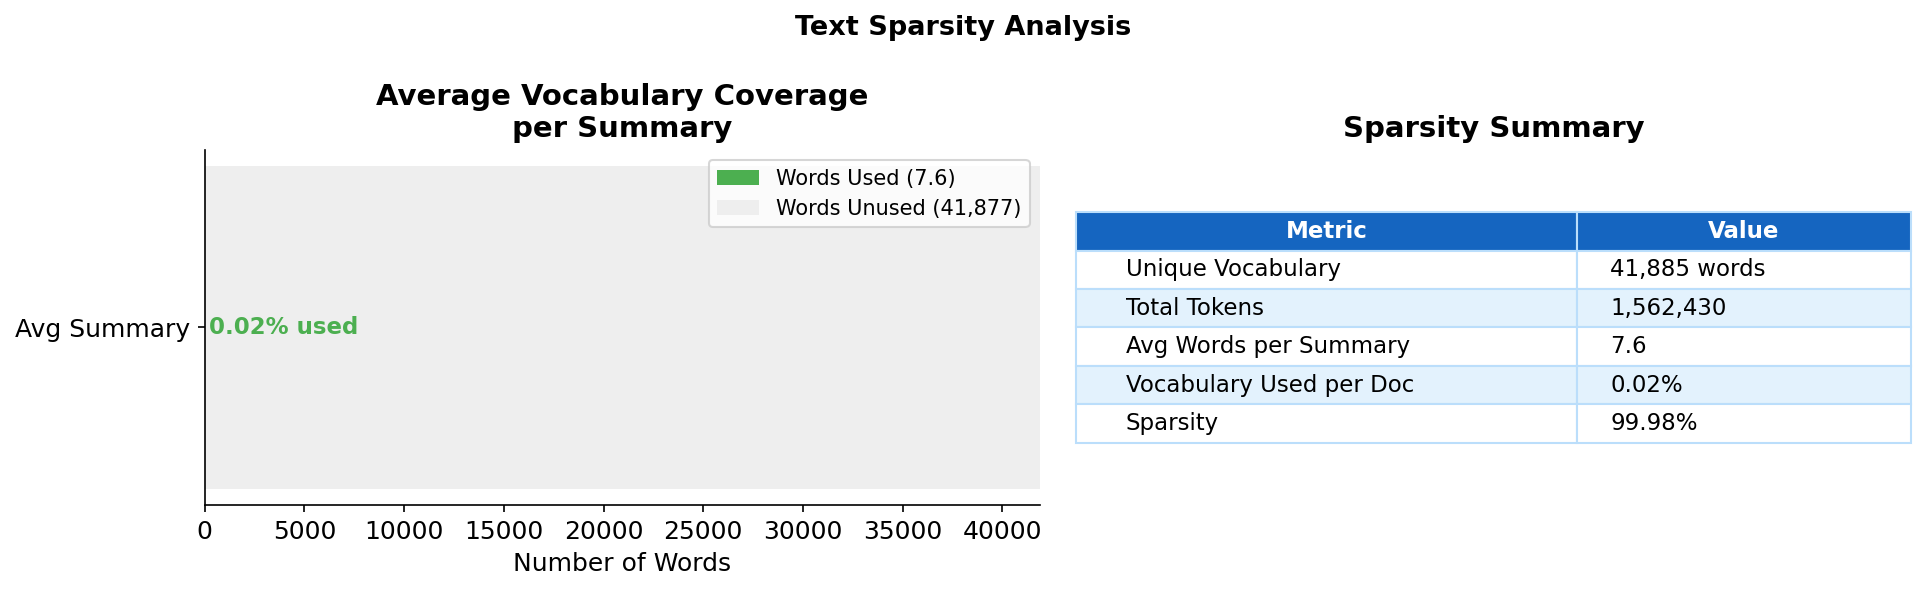

In [22]:
# Visualise sparsity — how much of the vocabulary each summary actually uses
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — stacked bar showing used vs unused vocabulary per document
used   = avg_per_doc
unused = vocab_size - avg_per_doc
axes[0].barh(['Avg Summary'], [used],   color='#4CAF50', label=f'Words Used ({used:.1f})')
axes[0].barh(['Avg Summary'], [unused], left=[used], color='#EEEEEE', label=f'Words Unused ({unused:,.0f})')
axes[0].set_xlabel('Number of Words')
axes[0].set_title('Average Vocabulary Coverage\nper Summary', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, vocab_size)
axes[0].text(used + 200, 0, f'{avg_per_doc/vocab_size*100:.2f}% used', va='center', fontsize=11, fontweight='bold', color='#4CAF50')

# Right — summary stats table
stats = [
    ['Unique Vocabulary',        f'{vocab_size:,} words'],
    ['Total Tokens',             f'{total_tokens:,}'],
    ['Avg Words per Summary',    f'{avg_per_doc:.1f}'],
    ['Vocabulary Used per Doc',  f'{avg_per_doc/vocab_size*100:.2f}%'],
    ['Sparsity',                 f'{(1 - avg_per_doc/vocab_size)*100:.2f}%'],
]
axes[1].axis('off')
t = axes[1].table(
    cellText=stats,
    colLabels=['Metric', 'Value'],
    cellLoc='left', loc='center', colWidths=[0.6, 0.4]
)
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1, 2.0)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#E3F2FD' if r % 2 == 0 else '#FFFFFF')
    cell.set_edgecolor('#BBDEFB')
axes[1].set_title('Sparsity Summary', fontweight='bold')

plt.suptitle('Text Sparsity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary of EDA Findings

In [23]:
# Consolidated summary of all EDA findings — informs data preparation and modelling decisions
print('=' * 62)
print('           EDA SUMMARY — KEY FINDINGS')
print('=' * 62)

print('Dataset:')
print(f'  Total records              : {len(df):,}')
print(f'  Null Summary rows          : 11 (dropped in cleaning)')
print(f'  Usable records             : {len(df.dropna(subset=["Summary"])):,}')

print('\nClass Imbalance:')
for sent in ['positive', 'negative', 'neutral']:
    tag = '— majority class' if sent == 'positive' else '— minority class' if sent == 'neutral' else ''
    print(f'  {sent.capitalize():10s}: {sentiment_counts[sent]:,} ({sentiment_pct[sent]}%) {tag}')

print('\nText Column Decision:')
print(f'  Review mean length         : {df["Review"].dropna().str.split().str.len().mean():.2f} words ({df["Review"].isna().mean()*100:.2f}% null)')
print(f'  Summary mean length        : {df["Summary"].dropna().str.split().str.len().mean():.2f} words ({df["Summary"].isna().mean()*100:.3f}% null)')

print('\nDuplicate Findings (grouped by product + Summary):')
print(f'  Exact duplicates           : {exact_dup:,} rows')
print(f'  Consistent label duplicates: {consistent_rows:,} rows')
print(f'  Label-conflicting rows     : {inconsistent_rows:,} rows (irresolvable noise)')

print('\nNoise Findings (Summary column):')
print(f'  Numbers                    : 15,784 (7.7%) — removed in normalisation')
print(f'  Concatenated tokens: {summary_stats["has_concat_tokens"]:,} — split using wordninja in normalisation')
print(f'  Punctuation / Special chars: minimal (<0.1%) — removed in normalisation')

print('\nModel Selection:')
print('  Summary length is short    : classical ML preferred over deep learning')
print('  4 models selected          : Logistic Regression, Naive Bayes,')
print('                               Linear SVM, Random Forest')
print('=' * 62)

           EDA SUMMARY — KEY FINDINGS
Dataset:
  Total records              : 205,052
  Null Summary rows          : 11 (dropped in cleaning)
  Usable records             : 205,041

Class Imbalance:
  Positive  : 166,581 (81.2%) — majority class
  Negative  : 28,232 (13.8%) 
  Neutral   : 10,239 (5.0%) — minority class

Text Column Decision:
  Review mean length         : 1.90 words (12.03% null)
  Summary mean length        : 7.76 words (0.005% null)

Duplicate Findings (grouped by product + Summary):
  Exact duplicates           : 34,374 rows
  Consistent label duplicates: 62,746 rows
  Label-conflicting rows     : 7,527 rows (irresolvable noise)

Noise Findings (Summary column):
  Numbers                    : 15,784 (7.7%) — removed in normalisation
  Concatenated tokens: 3,950 — split using wordninja in normalisation
  Punctuation / Special chars: minimal (<0.1%) — removed in normalisation

Model Selection:
  Summary length is short    : classical ML preferred over deep learning
  

---
# Data Preparation

---
## Step 1: Drop Null Summary Rows

In [24]:
# Drop the 11 rows where Summary is null — no text means unusable for classification
df_clean = df.dropna(subset=['Summary']).copy()

print(f'Rows before : {len(df):,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Rows dropped: {len(df) - len(df_clean):,}')

Rows before : 205,052
Rows after  : 205,041
Rows dropped: 11


---
## Step 2: Drop Corrupted Rate Rows

In [25]:
# Drop the 3 rows where Rate contains corrupted non-numeric values
# Valid ratings are 1–5 only — any other value is a data entry error
valid_rates = ['1', '2', '3', '4', '5']

before = len(df_clean)
df_clean = df_clean[df_clean['Rate'].isin(valid_rates)].copy()

print(f'Rows before : {before:,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Rows dropped: {before - len(df_clean):,}  ← corrupted Rate values removed')

Rows before : 205,041
Rows after  : 205,038
Rows dropped: 3  ← corrupted Rate values removed


---
## Step 3: Drop Exact Full-Row Duplicates

In [26]:
# Drop rows where every column is identical — likely crawling artifacts
before = len(df_clean)
df_clean = df_clean.drop_duplicates()

print(f'Rows before : {before:,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Rows dropped: {before - len(df_clean):,}')
rows_after_exact_dup = len(df_clean)


Rows before : 205,038
Rows after  : 170,664
Rows dropped: 34,374


---
## Step 4: Drop Label-Inconsistent Groups

In [27]:
# Identify groups where the same product+summary has conflicting sentiment labels
# These are irresolvable — the model cannot learn from contradictory examples
grp = df_clean.groupby(['product_name', 'Summary'])

conflict_keys = set()
for (prod, summ), group in grp:
    if len(group) > 1 and group['Sentiment'].nunique() > 1:
        conflict_keys.add((prod, summ))

before = len(df_clean)

# Vectorised filter — faster than row-wise .apply() on large DataFrames
df_clean['_key'] = list(zip(df_clean['product_name'], df_clean['Summary']))
df_clean = df_clean[~df_clean['_key'].isin(conflict_keys)].drop(columns='_key').reset_index(drop=True)

rows_after_label_noise = len(df_clean)

print(f'Conflicting groups identified: {len(conflict_keys):,}')
print(f'Rows before : {before:,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Rows dropped: {before - len(df_clean):,}')


Conflicting groups identified: 563
Rows before : 170,664
Rows after  : 167,605
Rows dropped: 3,059


---
## Step 5: Deduplicate Consistent Groups

In [28]:
# For same product+summary with consistent labels, keep only the first occurrence
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['product_name', 'Summary'])

print(f'Rows before : {before:,}')
print(f'Rows after  : {len(df_clean):,}')
print(f'Rows dropped: {before - len(df_clean):,}')
rows_after_dedup = len(df_clean)


Rows before : 167,605
Rows after  : 134,765
Rows dropped: 32,840


---
## Step 6: Class Imbalance Handling Decision

In [29]:
# Class imbalance: 81.2% positive, 13.8% negative, 5.0% neutral
# class_weight='balanced' applied to all four models — weights each class
# inversely to its frequency, same effect as resampling with no leakage risk.

print('=== CLASS DISTRIBUTION AFTER CLEANING ===')
dist = df_clean['Sentiment'].value_counts()
total = len(df_clean)
for label, count in dist.items():
    print(f'  {label.capitalize():10s}: {count:,} ({count/total*100:.1f}%)')

=== CLASS DISTRIBUTION AFTER CLEANING ===
  Positive  : 102,310 (75.9%)
  Negative  : 24,744 (18.4%)
  Neutral   : 7,711 (5.7%)


---
## Step 7: Drop Unused Columns

In [30]:
# Keep only Summary (model input) and Sentiment (label) — all other columns are not needed
df_clean = df_clean[['Summary', 'Sentiment']].reset_index(drop=True)

print(f'Final shape : {df_clean.shape}')
print(f'Columns kept: {df_clean.columns.tolist()}')
print(f'\nSentiment distribution after cleaning:')
print(df_clean['Sentiment'].value_counts())
df_clean.head()

Final shape : (134765, 2)
Columns kept: ['Summary', 'Sentiment']

Sentiment distribution after cleaning:
Sentiment
positive    102310
negative     24744
neutral       7711
Name: count, dtype: int64


,Summary,Sentiment
0,great cooler excellent air flow and for this p...,positive
1,best budget 2 fit cooler nice cooling,positive
2,the quality is good but the power of air is de...,positive
3,very bad product its a only a fan,negative
4,ok ok product,neutral


---
## Step 8: Text Normalisation

In [31]:
# Normalise text — lowercase, remove punctuation/numbers/special chars,
# and split concatenated tokens identified in noise analysis
def normalise_text(text):
    text = str(text).lower()                        # Convert to lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)          # Remove non-alphabetic characters
    # Send tokens ≥14 chars to wordninja — threshold based on actual data analysis:
    # legitimate long words (e.g. 'specifications', 'disappointment') are preserved,
    # merged tokens (e.g. 'productquality', 'deliverythanks') are correctly split
    words = text.split()
    words = [' '.join(wordninja.split(w)) if len(w) >= 14 else w for w in words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()        # Collapse multiple spaces
    return text

df_clean['Summary_clean'] = df_clean['Summary'].apply(normalise_text)

# Show sample before and after normalisation
print('Sample normalisation results:')
for orig, clean in zip(df_clean['Summary'].head(5), df_clean['Summary_clean'].head(5)):
    print(f'  Before: {orig}')
    print(f'  After : {clean}')
    print()

Sample normalisation results:
  Before: great cooler excellent air flow and for this price its so amazing and unbelievablejust love it
  After : great cooler excellent air flow and for this price its so amazing and unbelievable just love it

  Before: best budget 2 fit cooler nice cooling
  After : best budget fit cooler nice cooling

  Before: the quality is good but the power of air is decent
  After : the quality is good but the power of air is decent

  Before: very bad product its a only a fan
  After : very bad product its a only a fan

  Before: ok ok product
  After : ok ok product



---
## Step 9: Stopword Removal

In [32]:
# Remove NLTK English stopwords (179 words) from normalised text
def remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

df_clean['Summary_clean'] = df_clean['Summary_clean'].apply(remove_stopwords)

# Show sample after stopword removal
print('Sample after stopword removal:')
for orig, clean in zip(df_clean['Summary'].head(5), df_clean['Summary_clean'].head(5)):
    print(f'  Original : {orig}')
    print(f'  Processed: {clean}')
    print()

Sample after stopword removal:
  Original : great cooler excellent air flow and for this price its so amazing and unbelievablejust love it
  Processed: great cooler excellent air flow price amazing unbelievable love

  Original : best budget 2 fit cooler nice cooling
  Processed: best budget fit cooler nice cooling

  Original : the quality is good but the power of air is decent
  Processed: quality good power air decent

  Original : very bad product its a only a fan
  Processed: bad product fan

  Original : ok ok product
  Processed: ok ok product



---
## Step 10: Before vs After Preprocessing Comparison

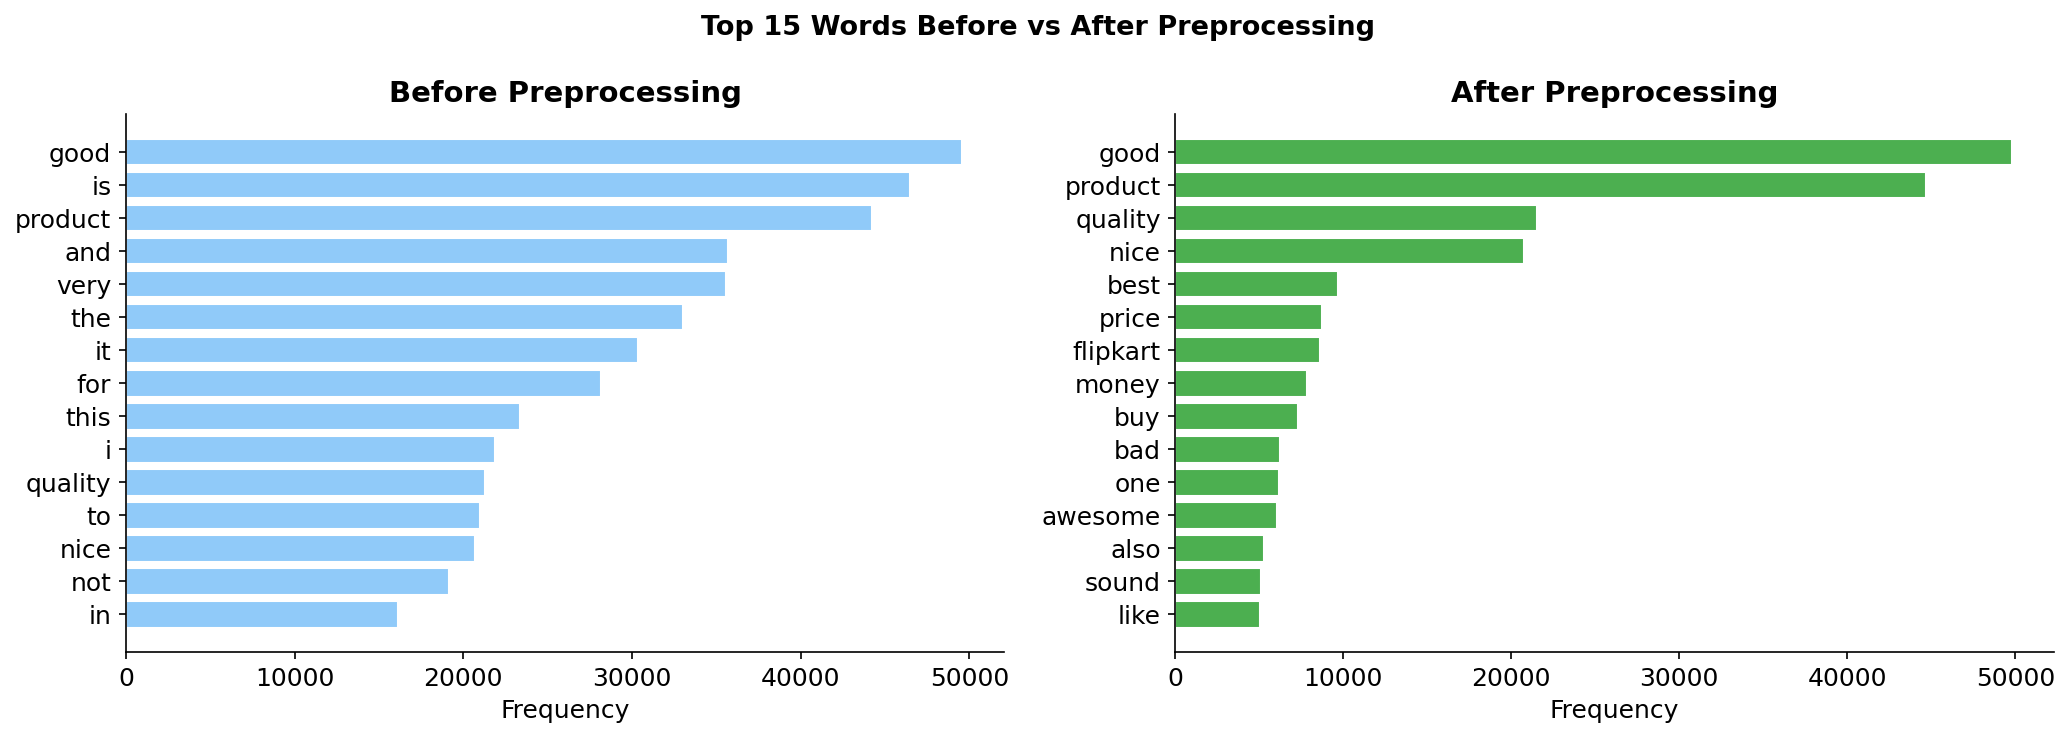

After preprocessing: stopwords removed, sentiment-bearing words dominate.


In [33]:
# Compare top 15 word frequencies before and after full preprocessing
def get_top_words(series, n=15):
    all_words = []
    for text in series.dropna():
        tokens = word_tokenize(str(text).lower())
        tokens = [w for w in tokens if w.isalpha()]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

top_before = get_top_words(df_clean['Summary'],       n=15)
top_after  = get_top_words(df_clean['Summary_clean'], n=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before preprocessing
words_b, counts_b = zip(*top_before)
axes[0].barh(words_b[::-1], counts_b[::-1], color='#90CAF9', edgecolor='white')
axes[0].set_title('Before Preprocessing', fontweight='bold')
axes[0].set_xlabel('Frequency')

# After preprocessing — meaningful sentiment words emerge
words_a, counts_a = zip(*top_after)
axes[1].barh(words_a[::-1], counts_a[::-1], color='#4CAF50', edgecolor='white')
axes[1].set_title('After Preprocessing', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Top 15 Words Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('After preprocessing: stopwords removed, sentiment-bearing words dominate.')

---
## Step 11: Train/Test Split

In [34]:
# Split dataset 80/20 with stratification to preserve class proportions
X = df_clean['Summary_clean']
y = df_clean['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Ensures each split preserves the class distribution
)

print(f'Training set size : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set size     : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')

# Confirm class distribution is preserved in both splits
print('\nClass distribution — Training set:')
print(y_train.value_counts())
print('\nClass distribution — Test set:')
print(y_test.value_counts())

Training set size : 107,812 (80.0%)
Test set size     : 26,953 (20.0%)

Class distribution — Training set:
Sentiment
positive    81848
negative    19795
neutral      6169
Name: count, dtype: int64

Class distribution — Test set:
Sentiment
positive    20462
negative     4949
neutral      1542
Name: count, dtype: int64


---
## Step 12: Empty Row Check After Split

In [35]:
# After preprocessing, some summaries become fully empty — e.g. raw text 'very', 'it is', 'so so'
# These had no meaningful content to begin with and are correctly removed
print('=== EMPTY ROW CHECK AFTER SPLIT ===')

# Check for both NaN and empty strings — preprocessing returns '' not NaN
empty_train = X_train.isna() | (X_train.str.strip() == '')
empty_test  = X_test.isna()  | (X_test.str.strip()  == '')

print(f'Empty Summary_clean in X_train : {empty_train.sum()}')
print(f'Empty Summary_clean in X_test  : {empty_test.sum()}')
print()
print('These summaries contained only stopwords or numbers in the raw data')
print('(e.g. "very", "it is", "so so", "0k") — no sentiment information.')
print('They are dropped before saving to avoid empty-string inputs to models.')
print()

# Drop empty and NaN rows and align labels
X_train = X_train[~empty_train]
y_train = y_train[~empty_train]
X_test  = X_test[~empty_test]
y_test  = y_test[~empty_test]

print(f'Train after dropping empty rows : {len(X_train):,}')
print(f'Test after dropping empty rows  : {len(X_test):,}')

=== EMPTY ROW CHECK AFTER SPLIT ===
Empty Summary_clean in X_train : 44
Empty Summary_clean in X_test  : 8

These summaries contained only stopwords or numbers in the raw data
(e.g. "very", "it is", "so so", "0k") — no sentiment information.
They are dropped before saving to avoid empty-string inputs to models.

Train after dropping empty rows : 107,768
Test after dropping empty rows  : 26,945


In [36]:
# Save train and test sets to CSV for use by all group members in Q2
os.makedirs('../Data', exist_ok=True)

train_df = pd.DataFrame({'Summary_clean': X_train, 'Sentiment': y_train})
test_df  = pd.DataFrame({'Summary_clean': X_test,  'Sentiment': y_test})

train_df.to_csv('../Data/train_set.csv', index=False)
test_df.to_csv('../Data/test_set.csv',  index=False)

print(f'train_set.csv saved : {len(train_df):,} rows')
print(f'test_set.csv saved  : {len(test_df):,} rows')

train_set.csv saved : 107,768 rows
test_set.csv saved  : 26,945 rows


---
## Data Preparation Summary

In [37]:
# Final dataset summary after all preparation steps
print('=' * 55)
print('      DATA PREPARATION SUMMARY')
print('=' * 55)
print(f'Original dataset rows        : {len(df):,}')
print(f'After dropping null Summary  : {len(df.dropna(subset=["Summary"])):,}')
print(f'After dropping exact dups    : {rows_after_exact_dup:,} rows')
print(f'After removing label noise   : {rows_after_label_noise:,} rows')
print(f'After deduplication          : {rows_after_dedup:,} rows')
print(f'\nColumns used for modelling   : Summary_clean (X), Sentiment (y)')
print(f'Training set                 : {len(X_train):,} rows')
print(f'Test set                     : {len(X_test):,} rows')
print(f'\nClass imbalance handling     : class_weight="balanced" on all models')
print(f'Models to train              : Logistic Regression, Naive Bayes,')
print(f'                               Linear SVM, Random Forest')
print('=' * 55)

      DATA PREPARATION SUMMARY
Original dataset rows        : 205,052
After dropping null Summary  : 205,041
After dropping exact dups    : 170,664 rows
After removing label noise   : 167,605 rows
After deduplication          : 134,765 rows

Columns used for modelling   : Summary_clean (X), Sentiment (y)
Training set                 : 107,768 rows
Test set                     : 26,945 rows

Class imbalance handling     : class_weight="balanced" on all models
Models to train              : Logistic Regression, Naive Bayes,
                               Linear SVM, Random Forest
